This is a notebook for computing deep foundation axial geotechnical capacity. <br>
Author: Zhiyan Jiang [(linkedin.com/in/zhiyanjiang)](http://www.linkedin.com/in/zhiyanjiang)

In [82]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Built-in and third-party libs

In [83]:
#import numpy as np
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

local libs

In [84]:
from deep_foundation_bearing_capacity.cross_sections.cross_sections import CircularSection, CrossSection
from deep_foundation_bearing_capacity.factor_of_safety.factor_of_safety import FactorOfSafetyDeepFoundation
from deep_foundation_bearing_capacity.foundation.deep_foundation import DeepFoundation
from deep_foundation_bearing_capacity.foundation.foundation_material import FoundationConcrete
from deep_foundation_bearing_capacity.geomaterials.layer import Layer
from deep_foundation_bearing_capacity.geomaterials.rock import Rock
from deep_foundation_bearing_capacity.geomaterials.soil import Soil
from deep_foundation_bearing_capacity.segments.segments import Segment
from deep_foundation_bearing_capacity.segments.unit_resistance import EndResistance, SideResistance

Project environment setup

In [85]:
def _find_project_root(marker = "pyproject.toml"):
    p = Path.cwd().resolve()
    while p != p.parent:
        if (p / marker).exists():
            return p
        else:
            p = p.parent
    raise FileNotFoundError(f"No {marker} found")

PROJECT_ROOT = _find_project_root()
#print(f"Project root is: {PROJECT_ROOT}")

In [86]:
logging.basicConfig(level = logging.DEBUG)

In [87]:
# Read rock parameters from YAML
with open(PROJECT_ROOT/"data/rock_params.yaml") as f:
    rocks_dict = yaml.safe_load(f)

rock_list = []
for rock_dict in rocks_dict:
    rock = Rock.from_dict(rock_dict)
    rock_list.append(rock)

    rock.display_properties()
    print()    

rock_index is: 0
unit_weight is: 150.0
friction_angle is: 30.0
qu is: 10000.0
rqd is: 100.0
rock_type is: A
rock_quality is: Excellent
rock_type_advanced is: None
joint is: open

rock_index is: 1
unit_weight is: 150.0
friction_angle is: 27.0
qu is: 10000.0
rqd is: 100.0
rock_type is: A
rock_quality is: Excellent
rock_type_advanced is: igm_cohesive
joint is: open

rock_index is: 2
unit_weight is: 150.0
friction_angle is: 30.0
qu is: 10000.0
rqd is: 90.0
rock_type is: A
rock_quality is: Very good
rock_type_advanced is: igm_cohesive
joint is: open



In [88]:
# Read layer parameters from YAML
with open(PROJECT_ROOT/"data/layer_params1.yaml") as f:
    layers_dict = yaml.safe_load(f)

layer_list = []
for layer_dict in layers_dict:
    layer = Layer.from_dict(layer_dict)
    layer_list.append(layer)
    

# Manually assign geomaterial
layer_list[0].geomaterial = rock_list[0]
layer_list[1].geomaterial = rock_list[1]
layer_list[2].geomaterial = rock_list[2]

for layer in layer_list:
    layer.display_properties(display_geomaterial=True)
    print()


layer_index is: 0
ground_water_depth is: 15.0
top_depth is: 0
thickness is: 10
rock_index is: 0
unit_weight is: 150.0
friction_angle is: 30.0
qu is: 10000.0
rqd is: 100.0
rock_type is: A
rock_quality is: Excellent
rock_type_advanced is: None
joint is: open

layer_index is: 1
ground_water_depth is: 15.0
top_depth is: 10
thickness is: 5
rock_index is: 1
unit_weight is: 150.0
friction_angle is: 27.0
qu is: 10000.0
rqd is: 100.0
rock_type is: A
rock_quality is: Excellent
rock_type_advanced is: igm_cohesive
joint is: open

layer_index is: 2
ground_water_depth is: 15.0
top_depth is: 15
thickness is: 10
rock_index is: 2
unit_weight is: 150.0
friction_angle is: 30.0
qu is: 10000.0
rqd is: 90.0
rock_type is: A
rock_quality is: Very good
rock_type_advanced is: igm_cohesive
joint is: open



In [89]:
# test SideResistance class for first layer
side_resistance_obj_1 = SideResistance.for_material(layer_list[0])
print(f"First layer alpha is: {side_resistance_obj_1._calculate_alpha():.2f}")
print(f"First layer phi is: {side_resistance_obj_1._calculate_phi()}")

# test SideResistance class for second layer
side_resistance_obj_2 = SideResistance.for_material(layer_list[1])
print(f"Second layer alpha is: {side_resistance_obj_2._calculate_alpha():.2f}")
print(f"Second layer phi is: {side_resistance_obj_2._calculate_phi()}")

# test SideResistance class for third layer
side_resistance_obj_3 = SideResistance.for_material(layer_list[2])
print(f"Third layer alpha is: {side_resistance_obj_3._calculate_alpha():.2f}")
print(f"Third layer phi is: {side_resistance_obj_3._calculate_phi()}")

First layer alpha is: 0.20
First layer phi is: 0.85
Second layer alpha is: 0.18
Second layer phi is: 0.85
Third layer alpha is: 0.23
Third layer phi is: 0.75


In [90]:
# test EndResistance class for cohesionsive IGM layer
end_resistance_obj_1 = EndResistance.for_material(layer_list[0])
print(f"Top layer unit end resistance is: {end_resistance_obj_1.end_resistance_unit(layer_list[0]):.2f}")

end_resistance_obj_2 = EndResistance.for_material(layer_list[1])
print(f"Second layer unit end resistance is: {end_resistance_obj_2.end_resistance_unit(layer_list[0]):.2f}")

end_resistance_obj_3 = EndResistance.for_material(layer_list[2])
print(f"Third layer unit end resistance is: {end_resistance_obj_3.end_resistance_unit(layer_list[0]):.2f}")

Top layer unit end resistance is: 38284.27
Second layer unit end resistance is: 38284.27
Third layer unit end resistance is: 14147.71


In [91]:
# test CrossSection class
cross_section_diameter = 1.5
print(f"Cross section diameter is: {cross_section_diameter}")
cross_section_obj = CircularSection(1.5)
print(f"Cross section area is: {cross_section_obj.cross_section_area:.2f}")
print(f"Cross section perimeter is: {cross_section_obj.perimeter:.2f}")

Cross section diameter is: 1.5
Cross section area is: 1.77
Cross section perimeter is: 4.71


In [92]:
# test Segment class
segment_obj_list = []
foundation_concrete_obj = FoundationConcrete()

for layer in layer_list:
    segment_obj = Segment(cross_section_obj, layer, foundation_concrete_obj)
    segment_obj_list.append(segment_obj)



In [93]:
print(f"Top segment side surface area is: {segment_obj_list[0].side_surface_area:.2f}")

Top segment side surface area is: 47.12


In [94]:
# test FactorOfSafety class
fs = 3.0
print(f"Factor of safety is prescribed as: {fs}")
fs_obj = FactorOfSafetyDeepFoundation(1, 1)

Factor of safety is prescribed as: 3.0


In [95]:
# test DeepFoundation class
top_depth = 0

deep_foundation_obj = DeepFoundation(segment_obj_list, top_depth,  resistance_corrections = None, fs = fs_obj)

# test DeepFoundation method for self weight
print(f"Concrete foundation self weight is: {deep_foundation_obj.effective_weight:.0f} lb.")

Concrete foundation self weight is: 5524 lb.


In [96]:
# test DeepFoundation method for calculating effective stress
print(f"Deep foundation effective stresses are: {deep_foundation_obj.calculate_segment_effective_stresses}")

Deep foundation effective stresses are: [750.0, 1875.0, 2688.0]


In [97]:
# test DeepFoundation side resistance
print("Below is compressive side resistance (lb.):")
print(deep_foundation_obj.calculate_segment_side_resistances(uplift = False))
print()
# test DeepFoundation side resistance for uplift
print("Below is uplift side resistance (lb.):")
print(deep_foundation_obj.calculate_segment_side_resistances(uplift = True))


Below is compressive side resistance (lb.):
[136983.88725529416, np.float64(35708.38873555117), np.float64(80707.26110138278)]

Below is uplift side resistance (lb.):
[136983.88725529416, np.float64(35708.38873555117), np.float64(80707.26110138278)]


In [98]:
# test DeepFoundation accumulative side resistance 
for segment_side_resistance_accumulative, segment_end_resistance in zip(
deep_foundation_obj.calculate_segment_side_resistances_accumulative(),
deep_foundation_obj.calculate_segment_end_resistances()
):
    print(f"{segment_side_resistance_accumulative:.0f}, {segment_end_resistance:.0f}")

136984, 67654
172692, 67654
253400, 25001


In [99]:
# test DeepFoundation accumulative compression resistance
print("Accumulative compression resistance is:")
for temp in deep_foundation_obj.calculate_compression_resistances_accumulative():
    print(f"{temp:.0f} lb.")

Accumulative compression resistance is:
204638 lb.
240346 lb.
278401 lb.


In [100]:
# test DeepFoundation calculate_segment_weights_accumulative
print("Accumulative self weight is: ")
deep_foundation_obj.calculate_segment_weights_effective_accumulative()

Accumulative self weight is: 


[2650.718801466388, 3976.078202199582, 5524.097982255953]

In [ ]:
# test DeepFoundation accumulative uplift resistance
print("Accumulative uplift resistance is:")
for temp in deep_foundation_obj.calculate_uplift_resistances_accumulative():
    print(f"{temp:.0f} lb.")

Accumulative compression resistance is:
139635 lb.
176668 lb.
258924 lb.


In [102]:
# Test plotting compression accumulative resistancedeep_foundation_obj.visualize_resistances_accumulative(target = "compression", style = "piecewise")

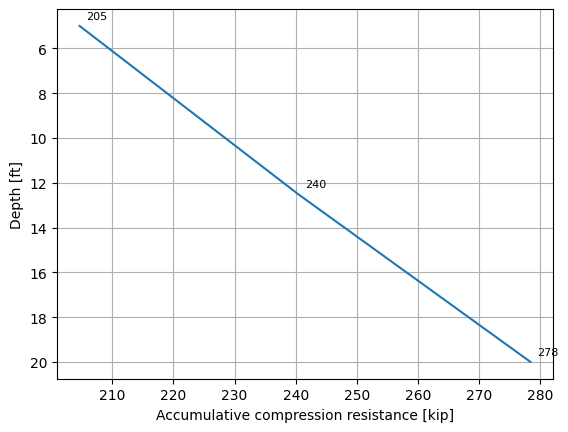

In [103]:
deep_foundation_obj.visualize_resistances_accumulative(target = "compression", style = "mid")

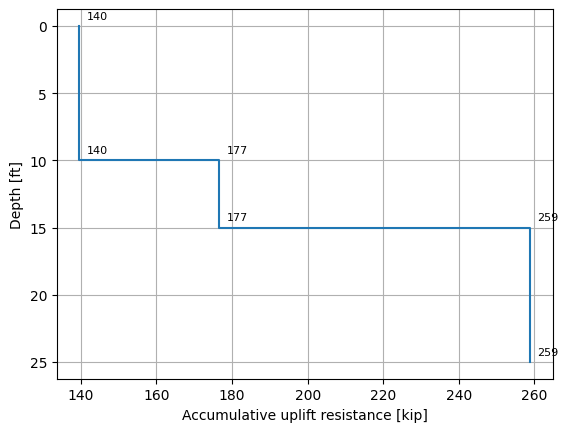

In [104]:
# Test plotting uplift accumulative resistance
deep_foundation_obj.visualize_resistances_accumulative(target = "uplift", style = "piecewise")


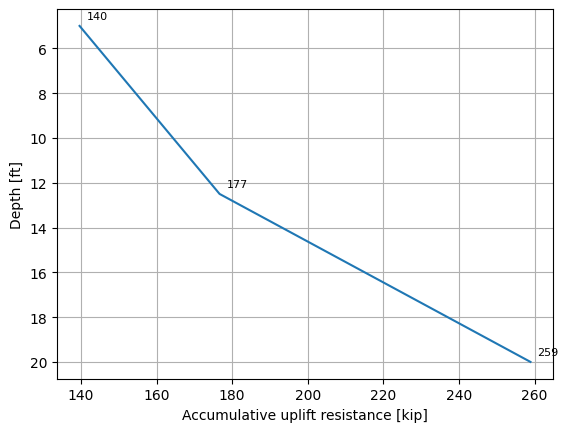

In [105]:
deep_foundation_obj.visualize_resistances_accumulative(target = "uplift", style = "mid")

In [106]:
# Test structural compression capacity
print("Each segment's structural capacity in compression is: ")
deep_foundation_obj.segments_structural_capacity_compression()

Each segment's structural capacity in compression is: 


[335899.0865218207, 335899.0865218207, 335899.0865218207]

In [107]:
# Test side resistance correction
#deep_foundation_obj = DeepFoundation([segment_obj_1, segment_obj_2], top_depth, resistance_correction=True)
#print(f"With depth correction, second segment side resistance is: {deep_foundation_obj.segments[1].side_resistance}")